# 4. Model Development

In [1]:
# Libraries imported for this notebook.

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [2]:
# Read EDA_Data.xlsx into a dataframe, formatted dates, and indexed dates.

df = pd.read_excel('/Users/NJahns/Desktop/Bootcamp/Capstone_Two/Edited_Data/Pre_Process_Train.xlsx', parse_dates=True, index_col=[0])

In [3]:
# Defined X, the target variable (SVI) and y, the features (treatment plant metrics).

X = df.drop(columns=['Sludge Volume Index'])
y = df['Sludge Volume Index']

A model capable of making predictions from time series data was essential for this project. I chose to use the random forest model because it meets these requirements, can adapt to non-linear patterns, resistant to overfitting, can handle seasonal trends, and is simpler than other options.

In [4]:
# Defined the Random Forest Regressor

rf = RandomForestRegressor()

I used TimeSeriesSplit as a cross-validator because it is specifically designed for time series data. The dataset is split into consecutive folds, where each fold is a superset of the previous one, ensuring that the model is trained on data that retains the temporal nature of time series data. In addition, these methods can also check for autocorrelation.

In [5]:
# Defined TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

In [6]:
# Initialized lists to store MSE scores and predictions

mse_scores = []
predictions = []

In [7]:
# Performed cross-validation and calculated mean squared error for each fold.

# Looped over each split for cross-validation
for train_index, test_index in tscv.split(X):
    # Split train and test datasets
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Fit the model
    rf.fit(X_train, y_train)
    
    # Predict on test set
    y_pred = rf.predict(X_test)
    
    # Calculate MSE
    mse = mean_squared_error(y_test, y_pred)
    mse_scores.append(mse)
    print("MSE:", mse)
    
    # Store predictions
    predictions.append(pd.Series(y_pred, index=X_test.index))

MSE: 11.39402500065705
MSE: 28.83265603784644
MSE: 94.54616466290805
MSE: 16.659353502513515
MSE: 4.457568650464774


Considering that the mean SVI value in the data 101 and the max is 235, we can say that four of the five MSEs are acceptable. The value of 97 indicates a large difference between the actual and predicted SVI values.

In [9]:
# Calculated model MSE score

model_mse = sum(mse_scores) / len(mse_scores)
print("Model MSE:", model_mse)

Model MSE: 31.177953570877964


The MSE for the model is acceptable. The value of 31 indicates a small difference between the actual and predicted SVI values.

In [10]:
# Calculated R2 model score

model_score = rf.score(X, y)
print("R2 Score:", model_score)

R2 Score: 0.995645206493005


The coefficient of determination indicates that 99.5% of the variance in SVI can be explained by the featuers included in the model, while the remaining 25% of the variance is unexplained and could be due to factors not accounted for in the model or random variability.

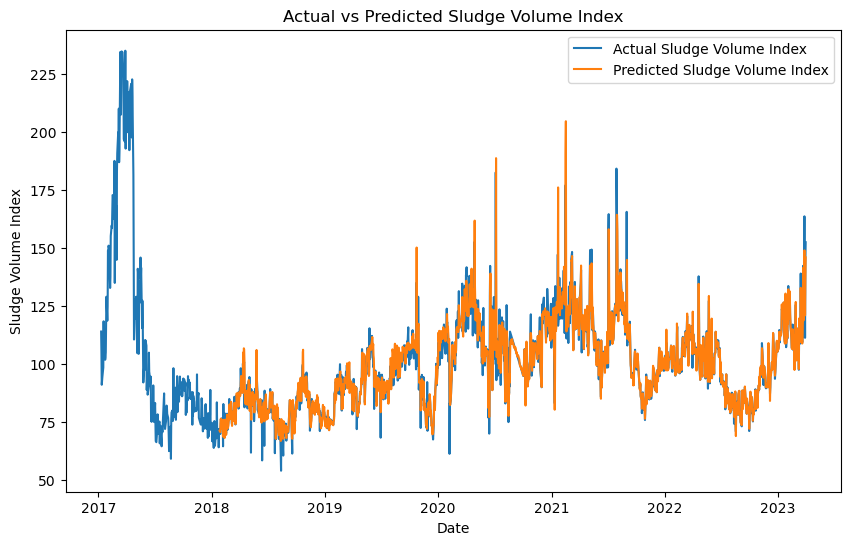

In [11]:
# Plotted actual vs predicted values

# Combined predictions into a single series
predicted_svi = pd.concat(predictions).sort_index()

# Plotted values
plt.figure(figsize=(10, 6))
plt.plot(df.index, df['Sludge Volume Index'], label='Actual Sludge Volume Index')
plt.plot(predicted_svi.index, predicted_svi, label='Predicted Sludge Volume Index')
plt.xlabel('Date')
plt.ylabel('Sludge Volume Index')
plt.title('Actual vs Predicted Sludge Volume Index')
plt.legend()
plt.show()

Actual and predicted values od SVI appear to be similar

In [12]:
# Extracted feature importances

feature_importances = rf.feature_importances_

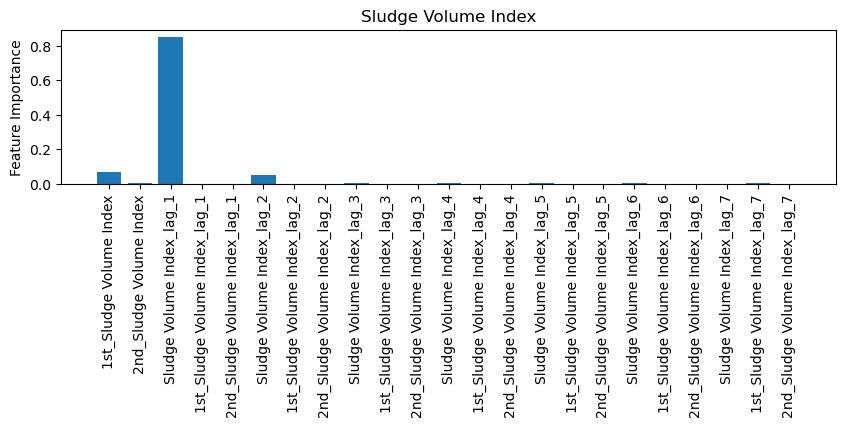

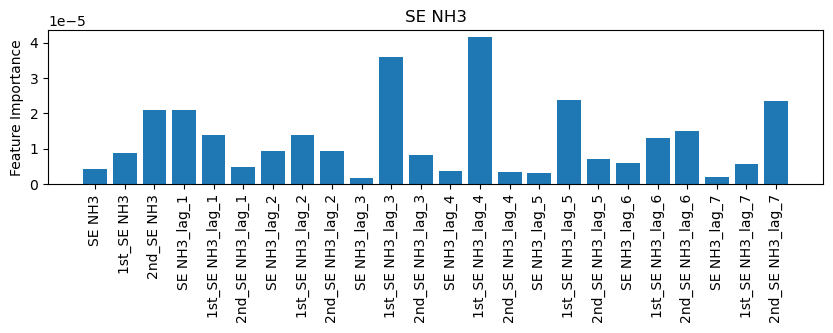

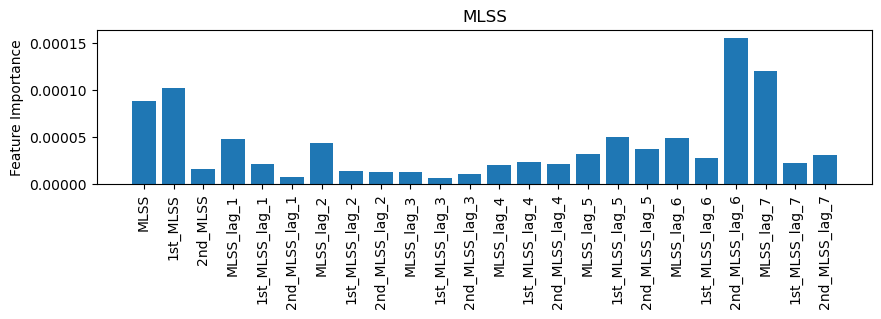

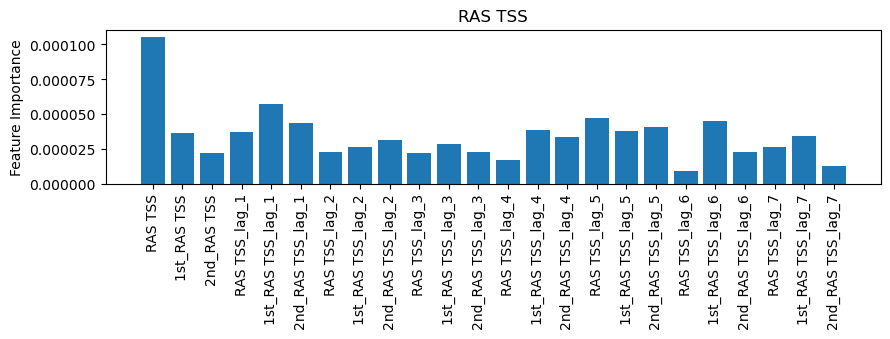

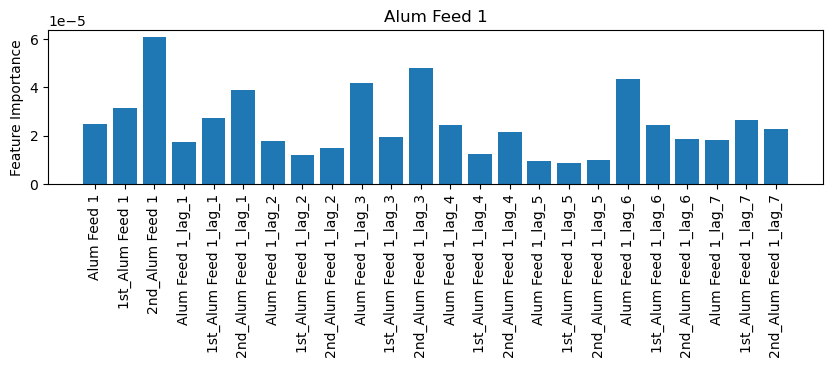

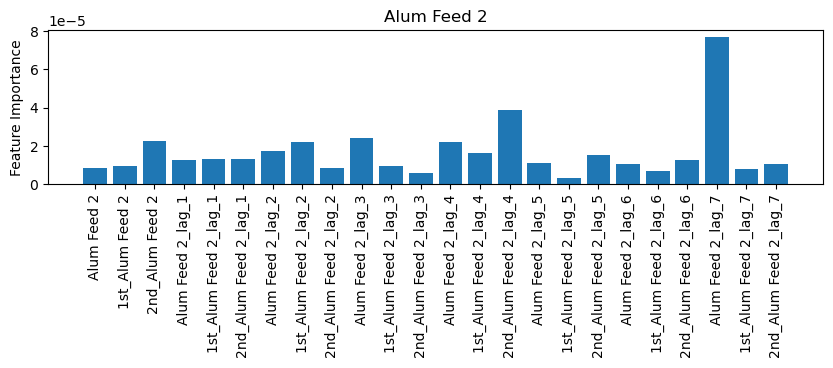

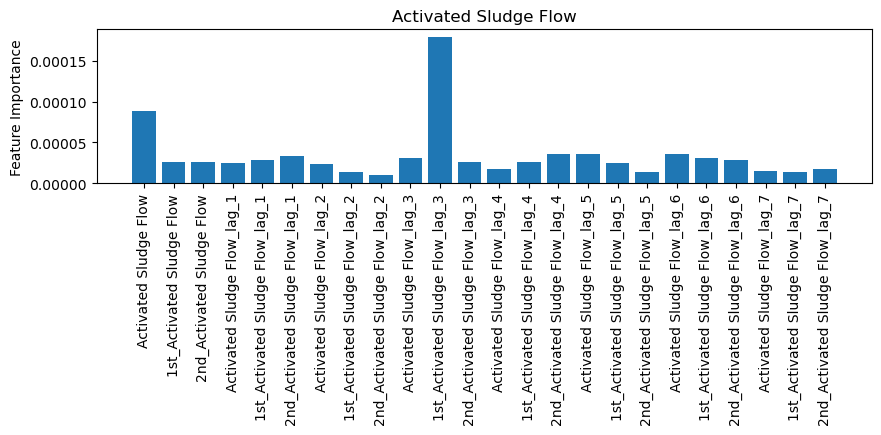

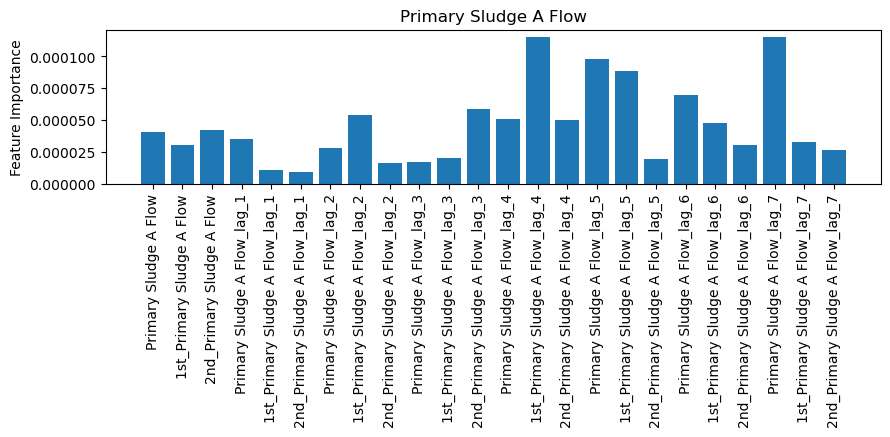

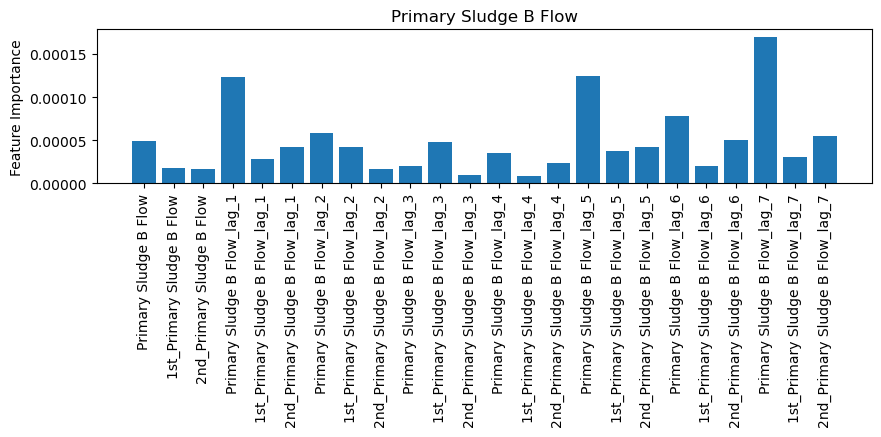

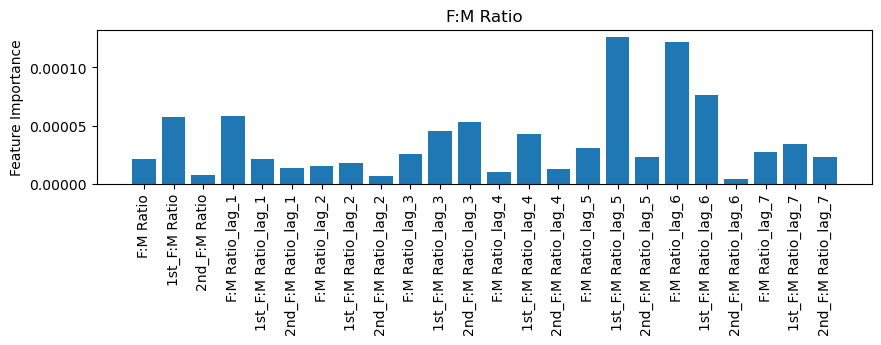

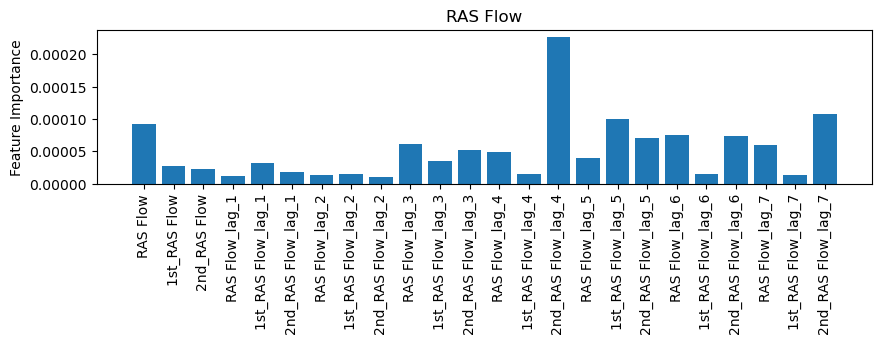

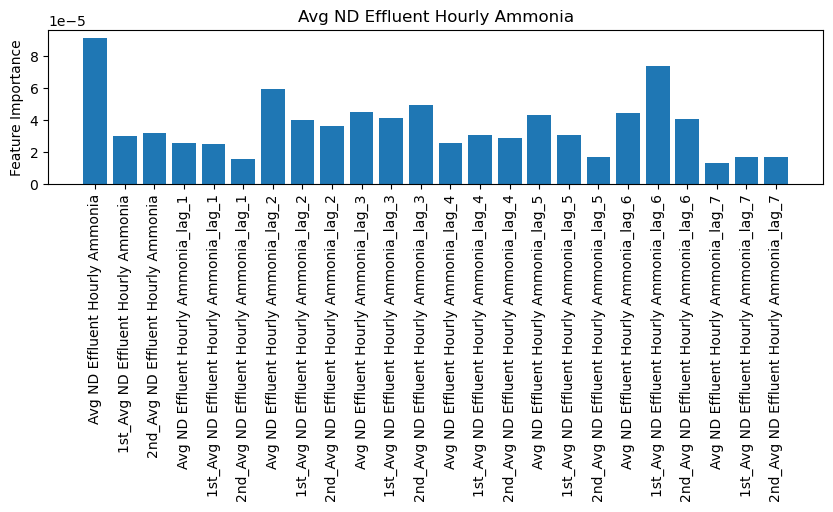

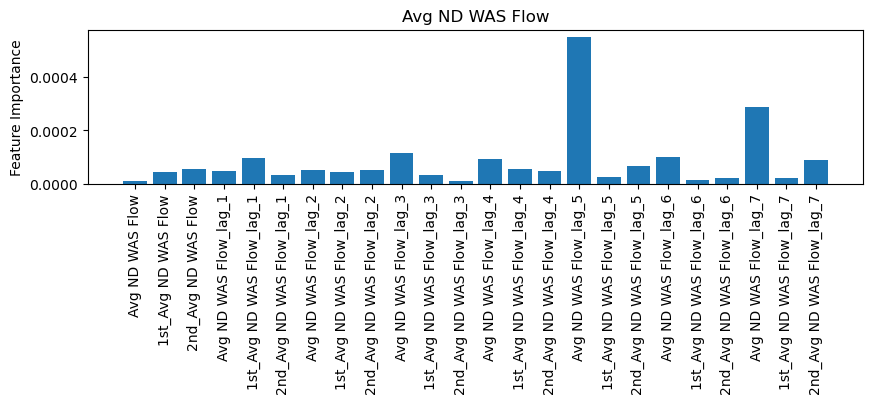

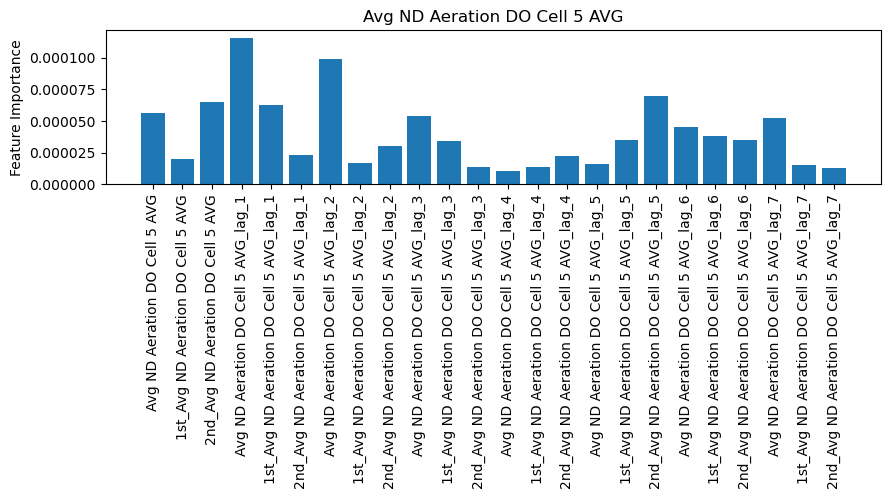

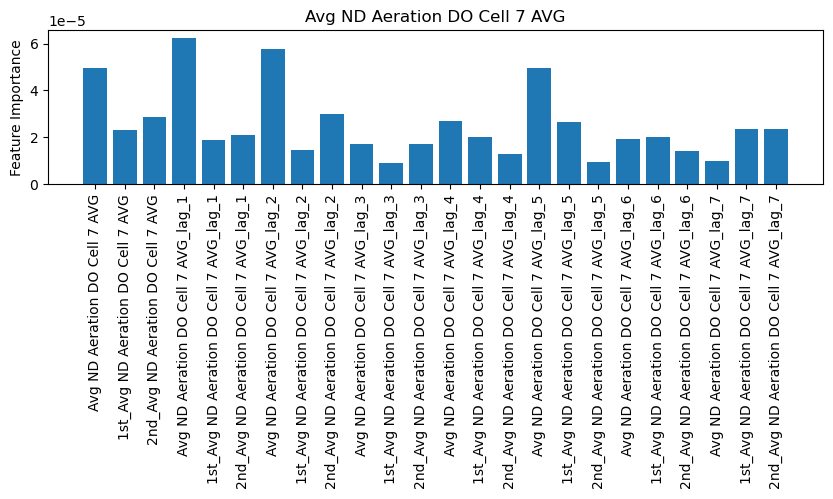

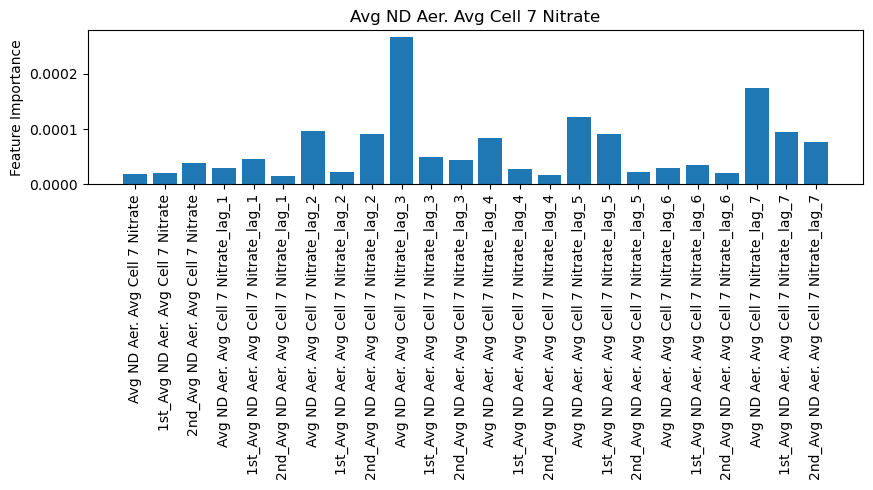

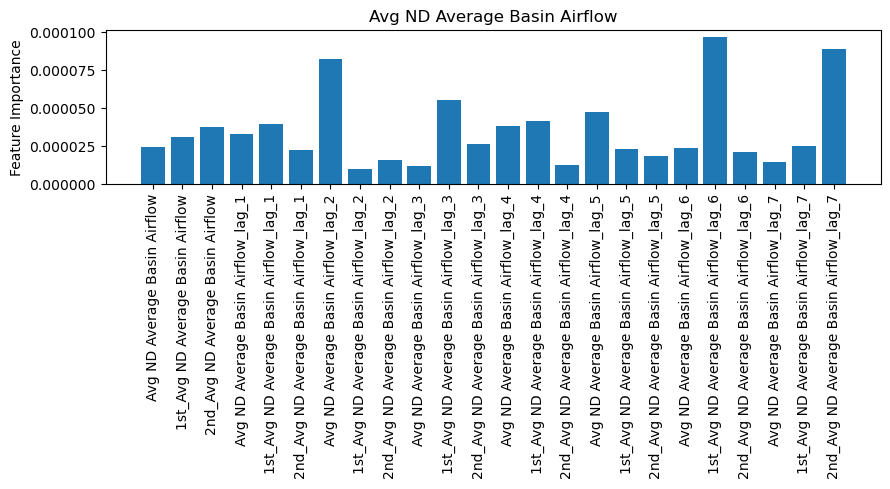

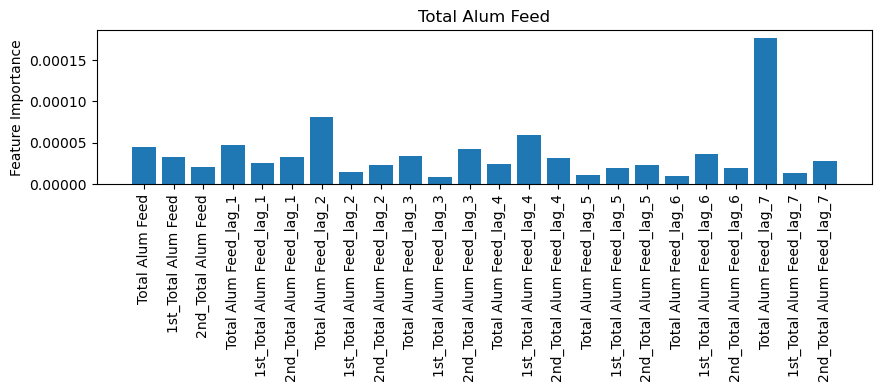

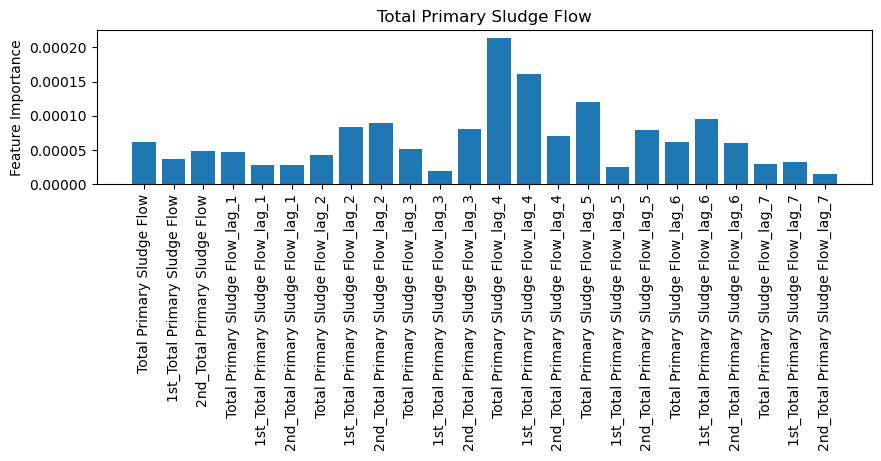

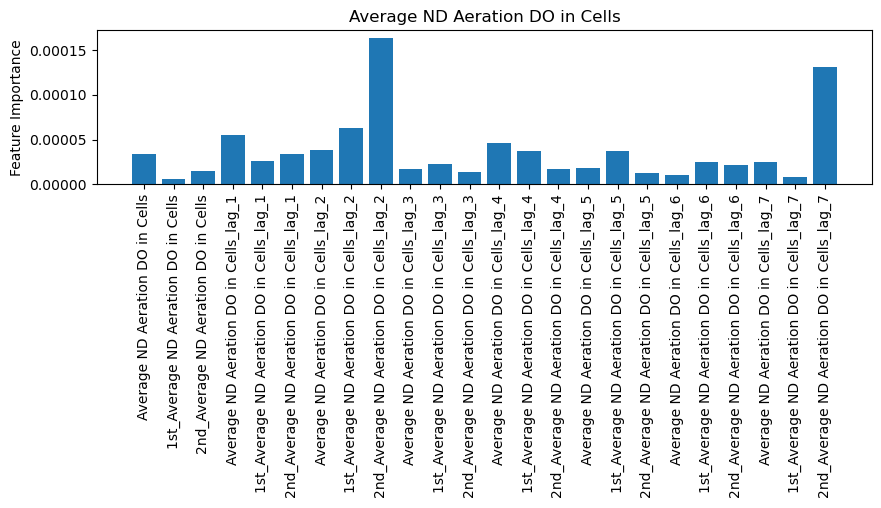

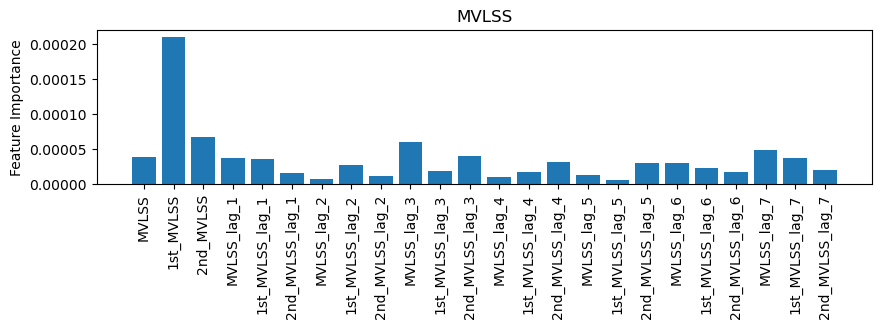

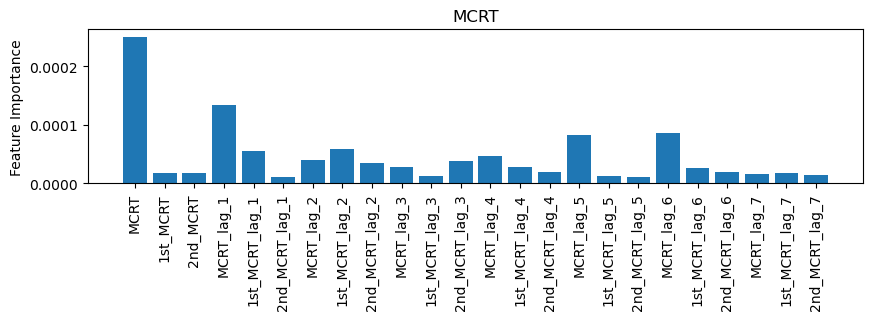

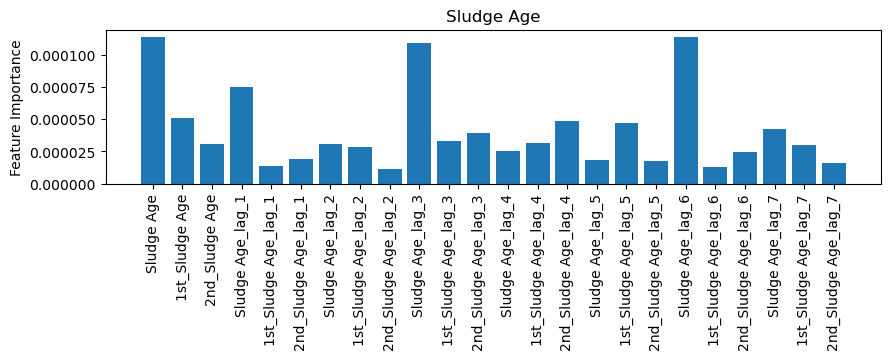

In [18]:
# Plotted feature importances

# Got the lagged feature names
feature_names = X.columns

# Define base feature names
base_feature_names = [
    'Sludge Volume Index',
    'SE NH3',
    'MLSS',
    'RAS TSS',
    'Alum Feed 1',
    'Alum Feed 2',
    'Activated Sludge Flow',
    'Primary Sludge A Flow',
    'Primary Sludge B Flow',
    'F:M Ratio',
    'RAS Flow',
    'Avg ND Effluent Hourly Ammonia',
    'Avg ND WAS Flow',
    'Avg ND Aeration DO Cell 5 AVG',
    'Avg ND Aeration DO Cell 7 AVG',
    'Avg ND Aer. Avg Cell 7 Nitrate',
    'Avg ND Average Basin Airflow',
    'Total Alum Feed',
    'Total Primary Sludge Flow',
    'Average ND Aeration DO in Cells',
    'MVLSS',
    'MCRT',
    'Sludge Age'
]

# Create a dictionary to store features grouped by their base feature name
feature_groups = {base_feature: [] for base_feature in base_feature_names}

# Group features by their base feature name
for feature_name in feature_names:
    for base_feature in base_feature_names:
        if base_feature in feature_name:
            feature_groups[base_feature].append(feature_name)
            break

# Create separate plots for each group of features
for base_feature, features in feature_groups.items():
    plt.figure(figsize=(10, 2))
    importance_values = [feature_importances[feature_names.tolist().index(feature)] for feature in features]
    plt.bar(range(len(features)), importance_values, align='center')
    plt.xticks(range(len(features)), features, rotation=90)
    plt.ylabel('Feature Importance')
    plt.title(f'{base_feature}')
    plt.show()

Few patterns in feature importance were observed. Amount of differencing or number of lagged days between the features do not appear to consistantly have a greater or lesser influence on the model.

In [16]:
# Identify the top 10 features with the highest importance
top_feature_indices = np.argsort(feature_importances)[::-1][:10]
top_features = [feature_names[i] for i in top_feature_indices]
top_scores = [feature_importances[i] for i in top_feature_indices]

# Print the top 10 features and their scores
print("Top 10 features for predicting SVI:")
for feature, score in zip(top_features, top_scores):
    print(f"{feature}: {score}")

Top 10 features for predicting SVI:
Sludge Volume Index_lag_1: 0.8510924814592544
1st_Sludge Volume Index: 0.06416638530669874
Sludge Volume Index_lag_2: 0.05035067305325717
Sludge Volume Index_lag_3: 0.005184322190910277
Sludge Volume Index_lag_4: 0.005078996384308817
2nd_Sludge Volume Index: 0.001006331457955332
Sludge Volume Index_lag_6: 0.0007335135754251956
Avg ND WAS Flow_lag_5: 0.0005501398191548828
Sludge Volume Index_lag_5: 0.0002896384414470452
Avg ND WAS Flow_lag_7: 0.0002856040135809248


The feature importance scores indicate that Sludge Volume Index value from the previouse day is the most important feature in predicting the current SVI and quite a bit more important than feaure in second place. Eight of the top 10 most iportant features are related to SVI indicating that the other features predict very little.

# Data save

In [20]:
# Saved to Excel.
df.to_excel('/Users/NJahns/Desktop/Bootcamp/Capstone_Two/Edited_Data/Model_Data.xlsx', index=True)